# ARISTA: model populations, communication and growth

Start here to calculate the inputs for Figure 5 and S19–S25 from the measured
ARISTA states and selected model. The default route loads the downloaded model;
the optional training cell can fit and select a new model instead.
Follow [installation](../../installation.md) and extract `arista_model.zip` and
`arista_analysis_data.zip` from the [data page](../../data_checkpoints.md).

Set `CYTOBRIDGE_PROJECT_DIR` to the folder containing `data/`. All four ARISTA
notebooks use `outputs/arista` (or `CYTOBRIDGE_ARISTA_OUTPUT_DIR`) and the device
in `CYTOBRIDGE_DEVICE`. Each calculation requires a new output directory.
The simulation, exported states and later numerical analyses need
about 0.5 GB; high-resolution figures may add several hundred MB.

In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import CytoBridge as cb
from IPython.display import Image, display

project = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
data = project / "data/arista"
analysis = Path(os.environ.get("CYTOBRIDGE_ARISTA_OUTPUT_DIR", project / "outputs/arista")).resolve()
device = os.environ.get("CYTOBRIDGE_DEVICE", "cuda")
populations = analysis / "populations"

def show(paths):
    for path in paths:
        if Path(path).suffix == ".png":
            display(Image(filename=str(path), width=850))

## Select the model, or train a new one

To train a new model, set `TRAIN_MODEL` to `True` below. The aligned input
contains the two spatial coordinates
and 50 PCA features. `fit` uses those features directly with the ARISTA full
training configuration and the supplied learned edge prior. Training writes
to a new directory and then selects that model
for the simulation and all following field calculations.

In [2]:
TRAIN_MODEL = False
model_dir = data / "model"
if TRAIN_MODEL:
    model_dir = analysis / "trained_model"
    if model_dir.exists():
        raise FileExistsError(f"Choose a new training directory: {model_dir}")
    training_config = Path(cb.__file__).resolve().parent / "configs/arista_spatial_full.yaml"
    trained = cb.tl.fit(
        data / "aligned.h5ad", config=str(training_config), device=device,
        time_key="time_point_processed", obsm_key="X_latent", is_spatial=True,
        spatial_key="spatial_aligned",
        edge_predictor_path=str(data / "edge_classifier/arista_edge_model.pt"),
        ckpt_dir=model_dir, evaluate_after_training=False)
print("Model:", model_dir)

Model: /data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-completion-20260905-r1/reader_project/data/arista/model


## Check the selected inputs

The joint feature order is two `spatial_aligned` coordinates followed by the
50 `X_latent` features. Model times 0–4 correspond to 2, 5, 10, 15 and 20 DPI.
The selected model directory supplies its Finetune and Score_Refine checkpoints.
The pretrained label classifier below has 53 inputs (time plus these 52 state
features) and uses 10-neighbour spatial smoothing.

In [3]:
classifier = data / "classifier_cache/classifier_resmlp_dedb1d6442f4d3d3.pt"
for path in [data / "aligned.h5ad", model_dir / "Finetune/best_model.pth",
             model_dir / "Score_Refine/score_model.pth", classifier]:
    if not path.is_file():
        raise FileNotFoundError(f"Extract the ARISTA model and analysis downloads first: {path}")
reference = ad.read_h5ad(data / "aligned.h5ad", backed="r")
display(reference.obs.groupby("time_point_processed", observed=True).size().rename("observed cells"))
reference.file.close()

time_point_processed
0.0     7668
1.0     8106
2.0     9436
3.0     9673
4.0    11316
Name: observed cells, dtype: int64

## Generate populations and model communication

`generate` starts with 7,668 cells, seed 42, split-SDE step 0.01, diffusion 0.03,
growth multiplier 1 and interaction groups of 1,024. It also follows a fixed
particle trajectory at step 0.05 for lineage. The measured populations are
retained at observed times; simulated populations supply the four intermediate
times. Coordinates remain unwarped.

The call exports the populations to `slice_data/`, `model_states/`,
`display_states/` and `generated_display_states/`.
`fixed_particle_lineage_labels.npz` tracks particle labels across time.
`all_time_communications.pkl` and `attention/*.npy` are computed from these model
states with self-loops retained and winsor quantile 0.995.
`post_simulation_rng.npz` stores the random state for Figure 5c's observed-field
calculation.

In [4]:
from reproduction.arista.simulate_paper_populations import generate
generate(data, populations, classifier, device=device, model_dir=model_dir)
display(pd.read_json(populations / "population_sizes.json"))

Interpolation enabled | interp_points= [0.5, 1.5, 2.5, 3.5] | observed_time_points= [0.0, 1.0, 2.0, 3.0, 4.0]
Loaded classifier cache in 0.0s | path=/data/cytobridge/projects/CytoBridge-ST-1104/runs/arista-package-native-spatialqc-z50-20260824-r1/downstream/classifier_cache/classifier_resmlp_dedb1d6442f4d3d3.pt | acc=0.7729437229437229 | bacc=0.6877649953746441
SDE n_samples (from t0): 7668
Simulating non-split SDE...
[simulate_sde_points] start | n_init=7668, ts_points=9, dt=0.05, sigma=0.0, include_score=False, t_range=(0.0,4.0), est_steps=80


[simulate_sde_points] done | timepoints=9, shape0=(7668, 52)
Non-split SDE done in 1.6s
Simulating split SDE...
[piecewise split-SDE] start | n_init=7668, ts_points=9, dt=0.01, sigma=0.03, daughter_noise_std=0.0, growth_alpha=1.0, resample_dt=None, t_range=(0.0,4.0), est_steps=400


[piecewise split-SDE] done | timepoints=9, shape0=(7668, 52)
Split SDE done in 7.7s


Time 0.0 cells 7668 of 7668
Time 0.5 cells 7780 of 7780
Time 1.0 cells 8106 of 8106
Time 1.5 cells 8608 of 8608
Time 2.0 cells 9436 of 9436
Time 2.5 cells 9684 of 9684


Time 3.0 cells 9673 of 9673
Time 3.5 cells 10035 of 10035
Time 4.0 cells 11316 of 11316
Saved: /data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-repair-20260907/arista/notebook_run_release/populations/all_time_communications.pkl


,time,observed_or_interpolated,generated
0,0.0,7668,7668
1,0.5,7780,7780
2,1.0,8106,8098
3,1.5,8608,8608
4,2.0,9436,9259
5,2.5,9684,9684
6,3.0,9673,9705
7,3.5,10035,10035
8,4.0,11316,11100


## Calculate growth and draw S20

Evaluate growth on every measured/intermediate model population. The table
`growth/growth_by_cell.csv.gz` contains all cells. The S20 renderer selects up
to 2,500 cells per time with seed 42 and computes the displayed sample's 5th and
95th percentile colour limits.

,count,median
time,,
0.0,7668,0.008724
0.5,7780,0.042492
1.0,8106,0.065417
1.5,8608,0.135147
2.0,9436,0.139348
2.5,9684,0.034058
3.0,9673,0.001539
3.5,10035,0.133032
4.0,11316,0.288400


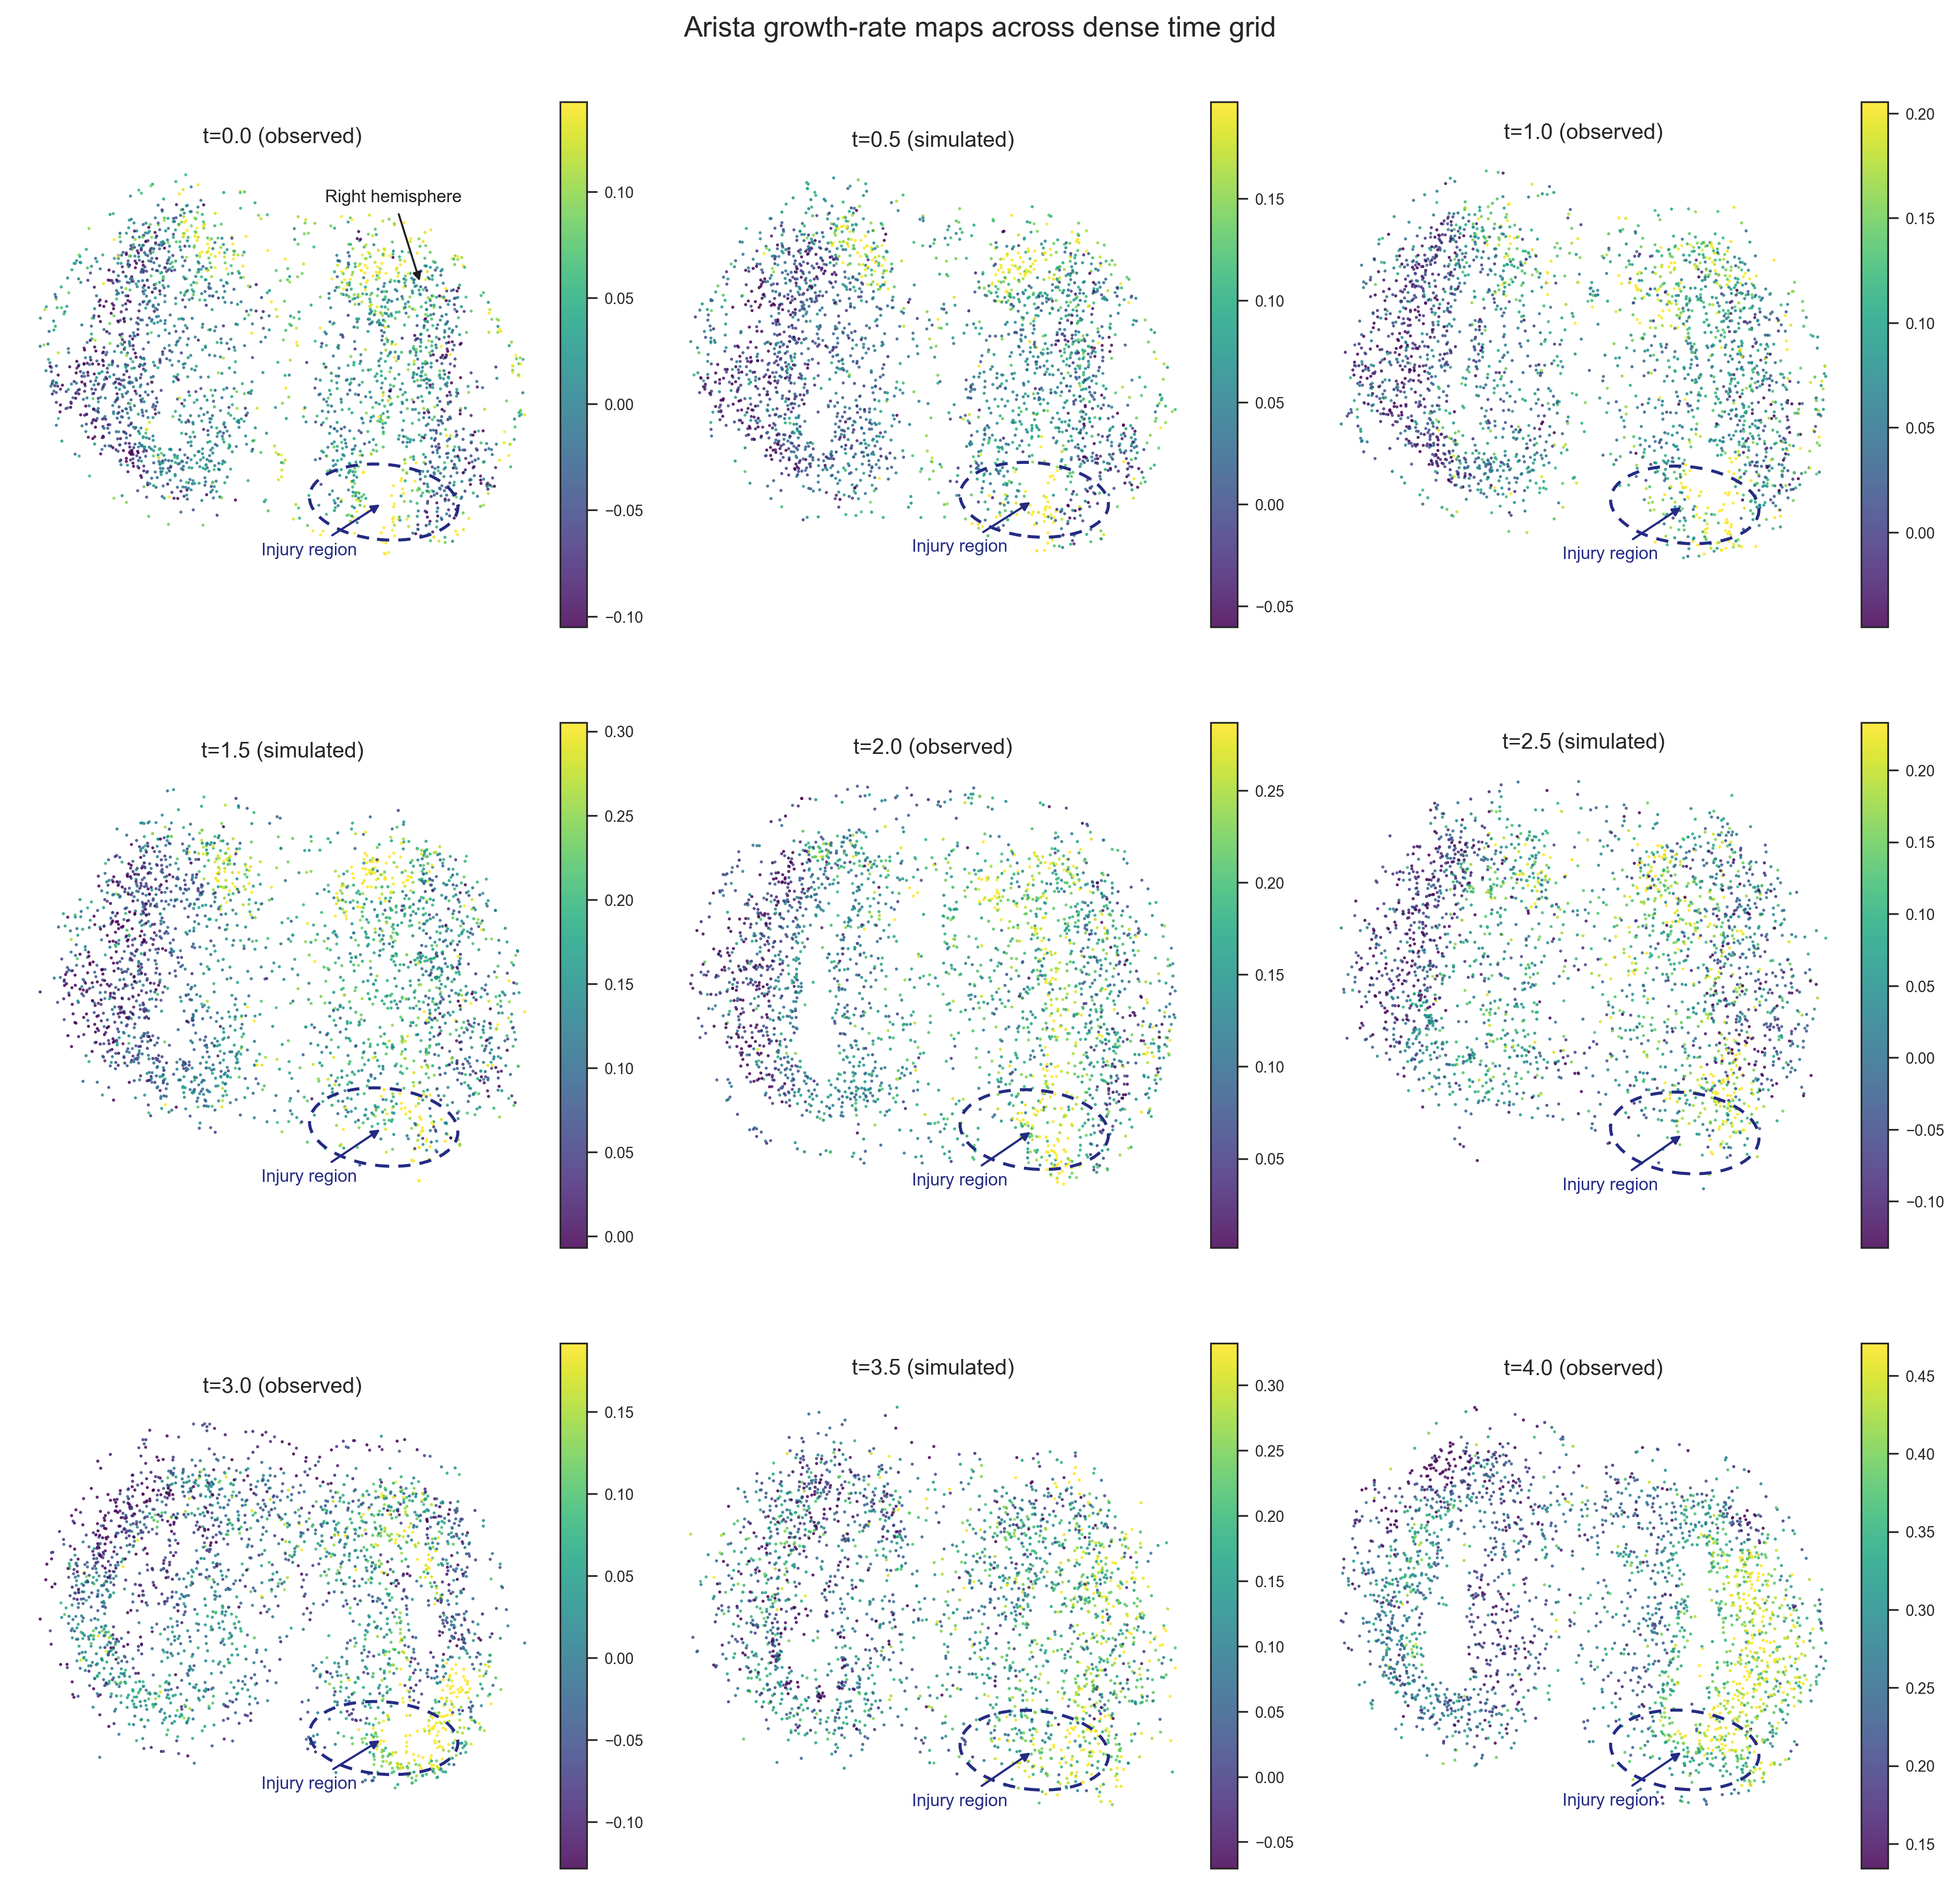

In [5]:
from reproduction.arista.analysis import calculate_growth
from reproduction.arista.supplementary import draw_supplementary
growth = calculate_growth(data, populations, analysis / "growth", device=device, model_dir=model_dir)
display(growth.groupby("time")["growth"].agg(["count", "median"]))
figures = draw_supplementary(analysis / "growth", analysis / "figures/S20", figures=[20])
show(figures[20])

## Continue with the same calculated run

[Figure 5](../paper_figures/main_figure_5.ipynb) reads `populations/` and calculates
its velocity fields. [S19–S24](../paper_figures/arista_figures.ipynb) reads those
populations and this growth table, then reconstructs gene and LR time courses.
[S25](../paper_figures/arista_local_domains.ipynb) follows their calculated
Figure 5c field, sparse attention and LR pair universe through domain segmentation
and cell-type-matched permutation tests. Keep the same project and analysis-directory settings.
`populations/model_selection.json` records the selected model directory for
those subsequent notebooks.

The observed-or-interpolated states retain measurements at observed times.
S19 separately shows the fully generated population at all nine times.